**IMPORTANDO**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sklearn.linear_model import LinearRegression

**Lendo o banco de dados**

In [ ]:
arq = pd.read_csv('/content/insurance.csv', encoding='latin1', sep=',')

**VISUALIZANDO AS PRIMEIRAS LINHAS**

In [ ]:
print(arq.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


**PEGANDO INFORMAÇÕES DAS COLUNAS**

In [ ]:
arq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# **GRÁFICO DE LINHA (MATPLOTLIB)**

/tmp/ipykernel_7706/3814181555.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arq_faixas = arq.groupby('faixa_idade')['charges'].mean().reset_index()


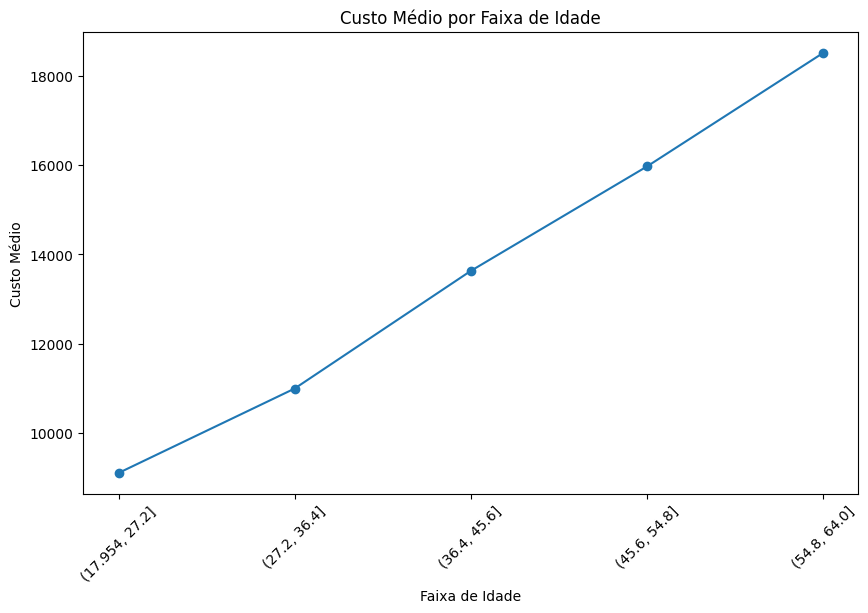

In [ ]:
arq['faixa_idade'] = pd.cut(arq['age'], bins=5)
arq_faixas = arq.groupby('faixa_idade')['charges'].mean().reset_index()

arq_faixas['faixa_idade'] = arq_faixas['faixa_idade'].astype(str)

plt.figure(figsize=(10,6))
plt.plot(arq_faixas['faixa_idade'], arq_faixas['charges'], marker='o')

plt.xticks(rotation=45)

plt.title('Custo Médio por Faixa de Idade')
plt.xlabel('Faixa de Idade')
plt.ylabel('Custo Médio')

plt.show()

**O gráfico de linha acima relaciona o custo médio por faixa de idade, podemos notar que conforme a idade aumenta os custos também tendem a crescer, mostrando que pessoas mais velhas costumam gastar mais com saúde. Porém, a idade não é o único fator que influencia nesses valores, já que outros aspectos como hábitos de vida e condições de saúde também podem impactar esses custos ao longo do tempo.**

# **GRÁFICO DE BARRA (MATPLOTLIB)**

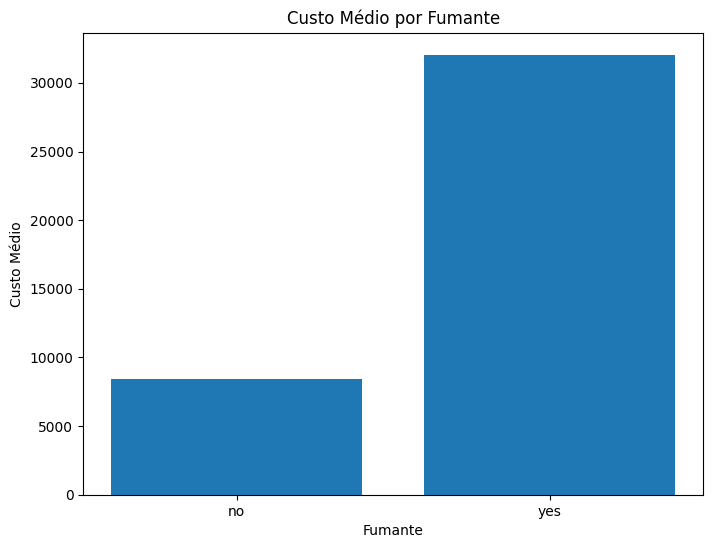

In [ ]:
media_smoker = arq.groupby('smoker')['charges'].mean()

plt.figure(figsize=(8,6))
plt.bar(media_smoker.index, media_smoker.values)

plt.title('Custo Médio por Fumante')
plt.xlabel('Fumante')
plt.ylabel('Custo Médio')

plt.show()

**O gráfico de barras acima relaciona o custo médio entre fumantes e não fumantes, podemos notar que existe uma diferença muito grande entre os dois grupos, sendo que os fumantes apresentam custos bem mais altos. Isso mostra que o hábito de fumar influencia diretamente nos gastos com saúde, embora outros fatores também possam interferir nesses valores.**

# **HISTOGRAMA (MATPLOTLIB)**

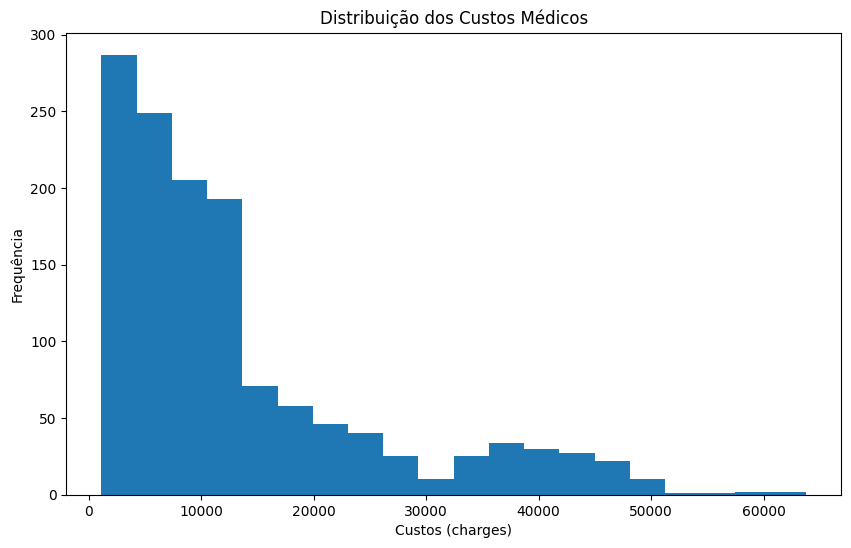

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(arq['charges'], bins=20)

plt.title('Distribuição dos Custos Médicos')
plt.xlabel('Custos (charges)')
plt.ylabel('Frequência')

plt.show()

**O histograma acima mostra a distribuição dos custos médicos, podemos notar que a maior parte dos valores se concentra em algumas faixas específicas, indicando um padrão nos gastos. Também é possível perceber que existem valores mais altos em menor quantidade, mostrando que algumas pessoas possuem custos muito maiores do que a média.**

**Analise das colunas**

In [ ]:
numericas = arq.select_dtypes(include=['int32','int64','float64'])
numericas.head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


# **HEATMAP DE CORRELAÇÃO (SEABORN)**

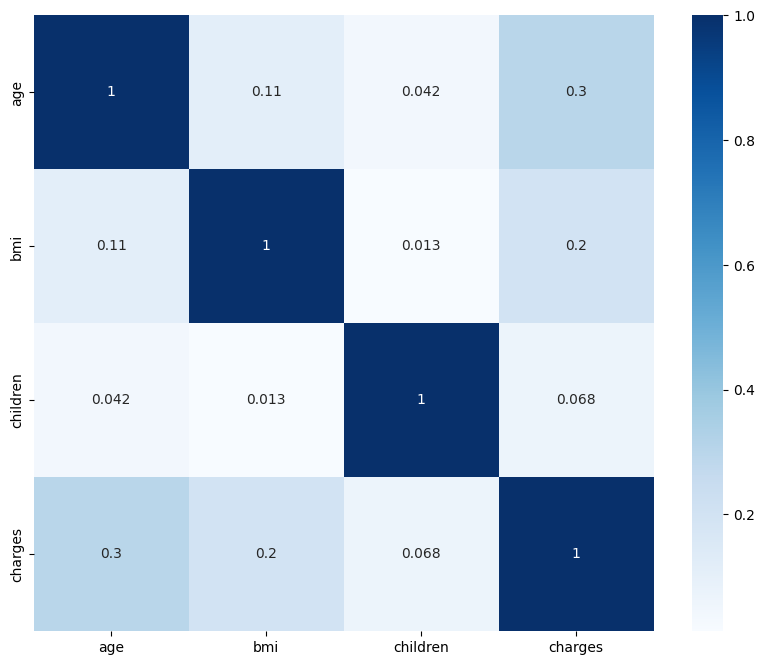

In [ ]:
numericas = arq.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numericas.corr(), annot=True, cmap="Blues")

plt.show()


**O heatmap acima mostra a correlação entre as variáveis numéricas do banco de dados, podemos notar que algumas apresentam uma relação moderada, como idade e custo, indicando que pessoas mais velhas tendem a gastar mais com saúde. Apesar disso, nem todas as variáveis possuem uma relação forte entre si, mostrando que os custos não dependem de um único fator, mas sim de uma combinação de diferentes características.**

# **BOXPLOT (SEABORN)**

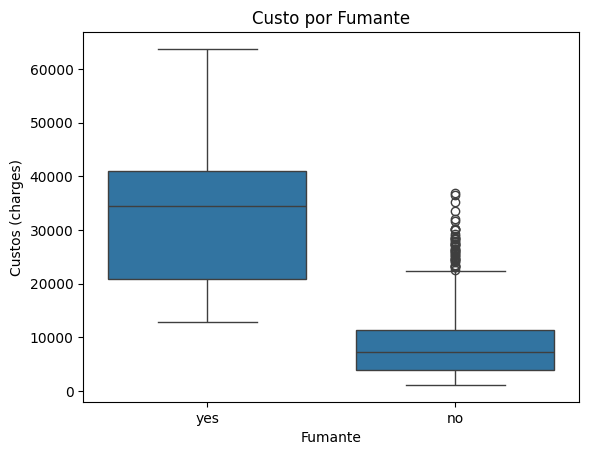

In [ ]:
sns.boxplot(data=arq, x='smoker', y='charges')

plt.title('Custo por Fumante')
plt.xlabel('Fumante')
plt.ylabel('Custos (charges)')

plt.show()

**O boxplot acima relaciona o fato de ser fumante ou não com os custos médicos, podemos notar que os fumantes apresentam valores muito mais altos e uma maior variação nos custos. Isso indica que o hábito de fumar é um dos fatores que mais impactam nos gastos com saúde dentro desse banco de dados.**

# **SCATTERPLOT (SEABORN)**

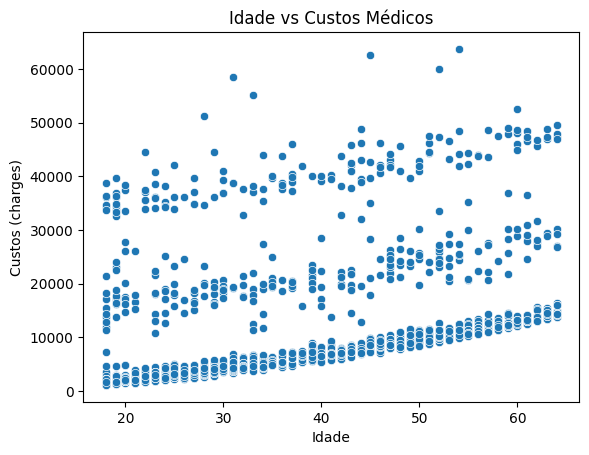

In [ ]:
sns.scatterplot(data=arq, x='age', y='charges')

plt.title('Idade vs Custos Médicos')
plt.xlabel('Idade')
plt.ylabel('Custos (charges)')

plt.show()

**O gráfico de dispersão acima relaciona a idade com os custos médicos, podemos notar que existe uma leve tendência de aumento dos custos conforme a idade cresce. Porém, os pontos ainda estão um pouco espalhados, indicando que a idade não é o único fator responsável pelos gastos, já que outras variáveis também influenciam nesses valores.**

# **REGRESSAO LINEAR**

In [ ]:
X = arq[['age']]
Y = arq['charges']

modelo = LinearRegression()
modelo.fit(X, Y)

a = modelo.coef_[0]
b = modelo.intercept_



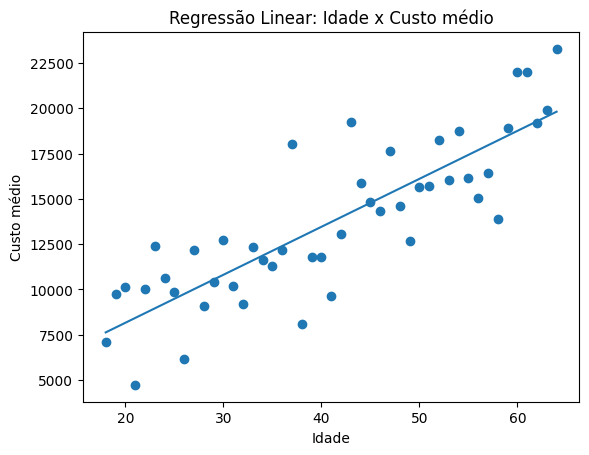

In [ ]:
arq_idade = arq.groupby('age')['charges'].mean().reset_index()

X = arq_idade[['age']]
Y = arq_idade['charges']

modelo = LinearRegression()
modelo.fit(X, Y)

y_pred = modelo.predict(X)

plt.scatter(X, Y)
plt.plot(X, y_pred)

plt.xlabel('Idade')
plt.ylabel('Custo médio')
plt.title('Regressão Linear: Idade x Custo médio')

plt.show()

**A regressão linear acima relaciona a idade com os custos médicos, podemos notar que a linha apresenta uma tendência de crescimento, indicando que quanto maior a idade, maiores tendem a ser os custos. Mesmo assim, os pontos ainda mostram certa dispersão, o que indica que essa relação não é perfeita e que outros fatores também influenciam os resultados.**

# **REGRESSÃO LINEAR COM MULTIPLAS VARIAVEIS**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = arq[['age', 'bmi', 'children']]
Y = arq['charges']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

modelo = LinearRegression()
modelo.fit(x_train, y_train)

y_test_pred = modelo.predict(x_test)

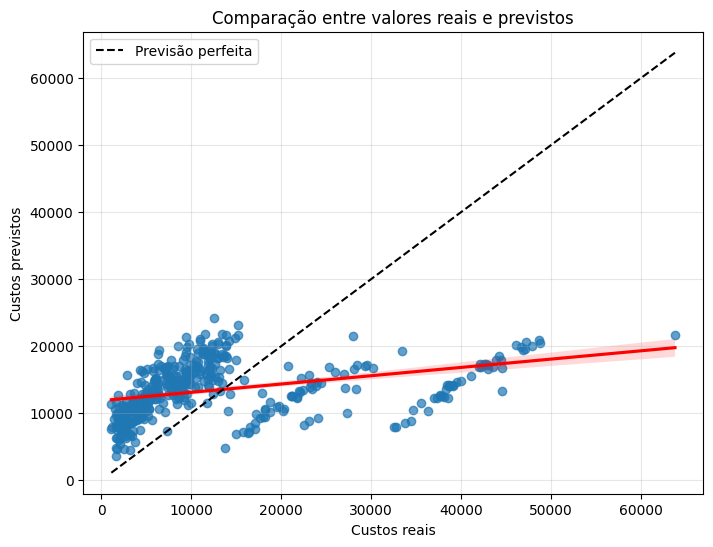

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=y_test,
    y=y_test_pred,
    scatter_kws={"alpha":0.7},
    line_kws={"color":"red"},
    ci=95
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="black",
    linestyle="--",
    label="Previsão perfeita"
)

plt.xlabel("Custos reais")
plt.ylabel("Custos previstos")
plt.title("Comparação entre valores reais e previstos")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**A regressão com múltiplas variáveis acima relaciona idade, índice de massa corporal e número de filhos com os custos médicos, podemos notar que o modelo tenta prever os valores reais a partir dessas informações. Observando o gráfico, percebemos que os pontos não ficam totalmente alinhados com a linha de previsão perfeita, indicando que o modelo não acerta exatamente todos os valores. Porém, ainda assim é possível ver uma tendência, mostrando que o modelo consegue captar parte do comportamento dos dados. Isso indica que os custos médicos não dependem apenas de uma variável isolada, mas sim da combinação de vários fatores, embora outros elementos que não estão presentes no banco também possam influenciar nesses resultados.**